# EDA on Product Details

### Objective

The objective of this analysis is to understand the structure, quality, and distribution of the Product Details dataset. The analysis focuses on:

- Understanding the dataset schema
- Identifying missing values
- Detecting duplicate records
- Validating product attributes
- Validating pricing information
- Analyzing category distribution
- Identifying potential data quality issues

The insights derived from this analysis will help ensure the dataset is reliable for downstream reporting and business analytics.

In [0]:
# Setting up the Path

# Set the storage account key in spark config
spark.conf.set(
    "fs.azure.account.key.retailsalesresources.blob.core.windows.net",
    dbutils.secrets.get("databricksScope", "storageaccount-secrets")  
)

# File path for raw-data container
RAW_DATA_PATH = "wasbs://raw-data@retailsalesresources.blob.core.windows.net"

# Loading the CSV files
product_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(f"{RAW_DATA_PATH}/product_details.csv")
)

## Dataset Overview

Before performing any analysis, it is important to understand the structure of the dataset, including the number of records, columns, and data types.

The results below provide a high-level overview of the Product Details dataset.

In [0]:
## Total row counts
print("Total rows are: ",product_df.count())


print("\n","=" *40)
print("Product details schema:")
product_df.printSchema()


print("\n","=" *40)
print("Total number of columns\n",len(product_df.columns))

Total rows are:  10

Product details schema:
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- price: integer (nullable = true)


Total number of columns
 4


## Descriptive Statistics

Descriptive statistics provide a summary of the numerical attributes in the dataset and help identify unusual values, missing information, and potential outliers.

The summary statistics for the dataset are shown below.

In [0]:
print("Product description\n")
product_df.describe().show()

Product description

+-------+------------------+------------+---------------+----------------+
|summary|        product_id|product_name|       category|           price|
+-------+------------------+------------+---------------+----------------+
|  count|                10|          10|             10|              10|
|   mean|             105.5|        NULL|           NULL|         62930.0|
| stddev|3.0276503540974917|        NULL|           NULL|70917.6682263783|
|    min|               101|Dining Table|       Clothing|            1300|
|    max|               110|          TV|Home Appliances|          250000|
+-------+------------------+------------+---------------+----------------+



## Missing Value Analysis

Missing values can affect both analytical results and downstream processing.

The following analysis identifies the number of missing values present in each column.

In [0]:
from pyspark.sql.functions import col, count, when

# Missing values per column
print("PRINTING MISSING VALUE COUNT PER COLUMNS")
product_df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in product_df.columns
]).show()

PRINTING MISSING VALUE COUNT PER COLUMNS
+----------+------------+--------+-----+
|product_id|product_name|category|price|
+----------+------------+--------+-----+
|         0|           0|       0|    0|
+----------+------------+--------+-----+



### Insights

No missing values were identified in any column of the Product Details dataset.

This indicates that the dataset is complete and does not require any missing value treatment.

## Distinct Value Analysis

Distinct value analysis helps understand the uniqueness and distribution of values within each column.

The results below show the distinct values present across the dataset.

In [0]:
for col in product_df.columns:
    print("\n","=" *40)
    print(f"Column name: {col}\n")
    
    # Displaying the columns
    product_df.select(col).distinct().show()

    # Displaying the per column count
    print(f"\nUnique {col} values are: ", product_df.select(col).distinct().count())


Column name: product_id

+----------+
|product_id|
+----------+
|       108|
|       101|
|       103|
|       107|
|       102|
|       109|
|       105|
|       110|
|       106|
|       104|
+----------+


Unique product_id values are:  10

Column name: product_name

+-------------+
| product_name|
+-------------+
|Mixer Grinder|
|           TV|
| Refrigerator|
|        Phone|
|       Laptop|
|    Microwave|
|         Sofa|
|        Shirt|
|        Shoes|
| Dining Table|
+-------------+


Unique product_name values are:  10

Column name: category

+---------------+
|       category|
+---------------+
|    Electronics|
|       Clothing|
|Home Appliances|
|      Furniture|
+---------------+


Unique category values are:  4

Column name: price

+------+
| price|
+------+
|  1300|
| 80000|
| 50000|
| 65000|
|250000|
| 15000|
| 70000|
|  8000|
| 45000|
+------+


Unique price values are:  9


In [0]:
duplicate_count = product_df.count() - product_df.dropDuplicates().count()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Insights

No duplicate records were identified in the Product Details dataset.

This indicates that each record represents a unique product entry.

## Product ID Validation

The Product ID serves as the primary identifier for products.

This validation verifies whether each Product ID is unique and ensures referential integrity across datasets.

In [0]:
from pyspark.sql.functions import count

product_df.groupBy("product_id") \
    .agg(count("*").alias("cnt")) \
    .filter("cnt > 1") \
    .show()

+----------+---+
|product_id|cnt|
+----------+---+
+----------+---+



### Insights

No duplicate Product IDs were identified.

This confirms that each product is uniquely represented within the dataset.

## Product Name Validation

The Product Name column was analyzed to identify missing values, blank entries, and potential inconsistencies.

The validation results are shown below.

In [0]:
from pyspark.sql.functions import col  

product_df.filter(
    (col("product_name").isNull()) |
    (col("product_name") == "")
).show()

+----------+------------+--------+-----+
|product_id|product_name|category|price|
+----------+------------+--------+-----+
+----------+------------+--------+-----+



### Insights

No missing or blank product names were identified.

The Product Name column appears complete and suitable for business reporting.

## Category Validation

The Category column was analyzed to understand the distribution of products across categories and identify potential inconsistencies.

The category distribution results are shown below.

In [0]:
product_df.groupBy("category") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+---------------+-----+
|       category|count|
+---------------+-----+
|    Electronics|    3|
|Home Appliances|    3|
|       Clothing|    2|
|      Furniture|    2|
+---------------+-----+



%md
### Insights

The category values appear consistent and do not contain any obvious anomalies or invalid entries.

The distribution provides a clear view of product concentration across categories.

## Price Validation

The Price column was validated to identify invalid values such as negative prices, zero prices, and other pricing anomalies.

The validation results are shown below.

In [0]:
# Checking for negetive prices
product_df.filter(col("price") < 0).show()

+----------+------------+--------+-----+
|product_id|product_name|category|price|
+----------+------------+--------+-----+
+----------+------------+--------+-----+



In [0]:
# Cheking for prices equal to zero
product_df.filter(col("price") == 0).show()

+----------+------------+--------+-----+
|product_id|product_name|category|price|
+----------+------------+--------+-----+
+----------+------------+--------+-----+



## Price Outlier Analysis

Outlier analysis was performed to identify products with unusually high or low prices.

These observations help detect potential data entry errors and understand pricing variation within the catalog.

In [0]:
product_df.select("price").summary().show()

+-------+----------------+
|summary|           price|
+-------+----------------+
|  count|              10|
|   mean|         62930.0|
| stddev|70917.6682263783|
|    min|            1300|
|    25%|           15000|
|    50%|           45000|
|    75%|           70000|
|    max|          250000|
+-------+----------------+



### Insights

The summary statistics provide visibility into the overall price distribution and help identify potential outliers requiring further investigation.

## Category Distribution Analysis

Understanding category distribution helps identify dominant product groups and assess the composition of the product catalog.

The category distribution visualization is shown below.

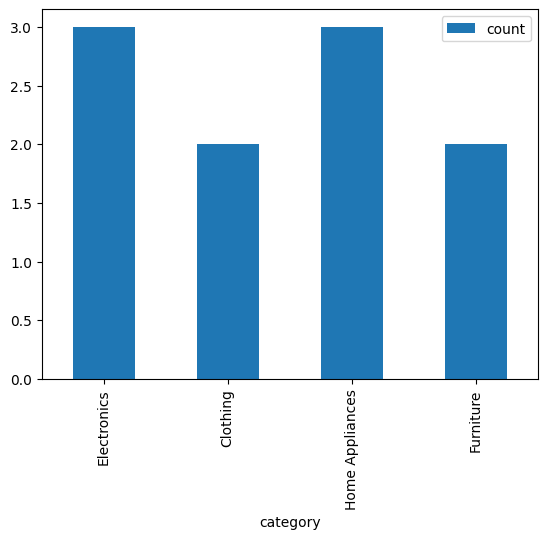

In [0]:
import matplotlib.pyplot as plt

category_counts = (
    product_df.groupBy("category")
    .count()
    .toPandas()
)

category_counts.plot(
    x="category",
    y="count",
    kind="bar"
)

plt.show()

## Price Distribution Analysis

Price distribution analysis helps understand pricing patterns, skewness, and potential concentration of products within specific price ranges.

The distribution visualization is shown below.

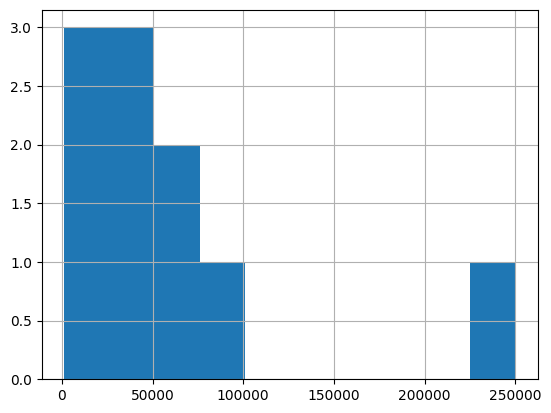

In [0]:
price_pd = product_df.select("price").toPandas()

price_pd["price"].hist()
plt.show()

# Final Conclusion

The exploratory data analysis of the Product Details dataset has been successfully completed.

### Key Findings

- The dataset schema and structure were reviewed and validated.
- No significant missing value issues were identified.
- Duplicate record checks were performed to ensure data quality.
- Product IDs were validated to confirm uniqueness.
- Product names and categories were reviewed for completeness and consistency.
- Price validation was performed to identify invalid pricing records.
- Outlier analysis was conducted to assess price distribution.
- Category and price distribution analyses provided insights into the composition of the product catalog.

### Outcome

The Product Details dataset has been thoroughly profiled and validated. The results indicate that the dataset is suitable for downstream reporting, analytics, and business intelligence workloads.